<a href="https://colab.research.google.com/github/Ini-Amin/Proyek-Klasifikasi-Gambar-Brain-Tumor-BRISC-2025/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyek Klasifikasi Gambar: Brain Tumor Classification (BRISC 2025)
- **Nama:** Aminadab Yunus
- **Email:** lithium7b@gmail.com
- **ID Dicoding:** apc355d6y0053

## Import Semua Packages/Library yang Digunakan

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data Preparation

### Data Loading

Dataset yang digunakan adalah **BRISC 2025 - Brain Tumor Classification** dari Kaggle.
Hanya folder `train` yang didownload, kemudian di-split manual menjadi **train / validation / test**.

Kelas:
- `glioma` — tumor glioma
- `meningioma` — tumor meningioma
- `pituitary` — tumor pituitary
- `no_tumor` — tidak ada tumor


In [2]:
from google.colab import userdata
import os

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY']      = userdata.get('KAGGLE_KEY')

!pip install -q kaggle
print('Kaggle API siap!')


Kaggle API siap!


In [3]:
import shutil

# Ganti DATASET_SLUG dengan slug dataset BRISC di Kaggle
# Cara cari: buka halaman dataset Kaggle → lihat URL-nya
# Contoh URL: kaggle.com/datasets/USERNAME/DATASET-SLUG
DATASET_SLUG = 'briscdataset/brisc2025'  # <-- GANTI INI
EXTRACT_DIR  = '/content/dataset'
TRAIN_SRC    = os.path.join(EXTRACT_DIR, 'brisc2025', 'classification_task', 'train')

if not os.path.exists(TRAIN_SRC):
    print('Mulai download dataset...')
    !kaggle datasets download -d {DATASET_SLUG} -p {EXTRACT_DIR} --unzip
    print('Download selesai!')
else:
    print('Dataset sudah ada, skip download.')

!find {TRAIN_SRC} -type d


Mulai download dataset...
Dataset URL: https://www.kaggle.com/datasets/briscdataset/brisc2025
License(s): Attribution 4.0 International (CC BY 4.0)
100% 250M/250M [00:02<00:00, 127MB/s]

Download selesai!
/content/dataset/brisc2025/classification_task/train
/content/dataset/brisc2025/classification_task/train/no_tumor
/content/dataset/brisc2025/classification_task/train/meningioma
/content/dataset/brisc2025/classification_task/train/pituitary
/content/dataset/brisc2025/classification_task/train/glioma


In [4]:
# Info jumlah gambar per kelas (dari folder train Kaggle)
classes = sorted(os.listdir(TRAIN_SRC))
print(f'Kelas: {classes}')
print(f'Jumlah kelas: {len(classes)}')
print()

total = 0
for cls in classes:
    n = len(os.listdir(os.path.join(TRAIN_SRC, cls)))
    total += n
    print(f'  {cls:<15} : {n:>5} gambar')

print(f'\nTotal keseluruhan: {total} gambar')


Kelas: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Jumlah kelas: 4

  glioma          :  1147 gambar
  meningioma      :  1329 gambar
  no_tumor        :  1067 gambar
  pituitary       :  1457 gambar

Total keseluruhan: 5000 gambar


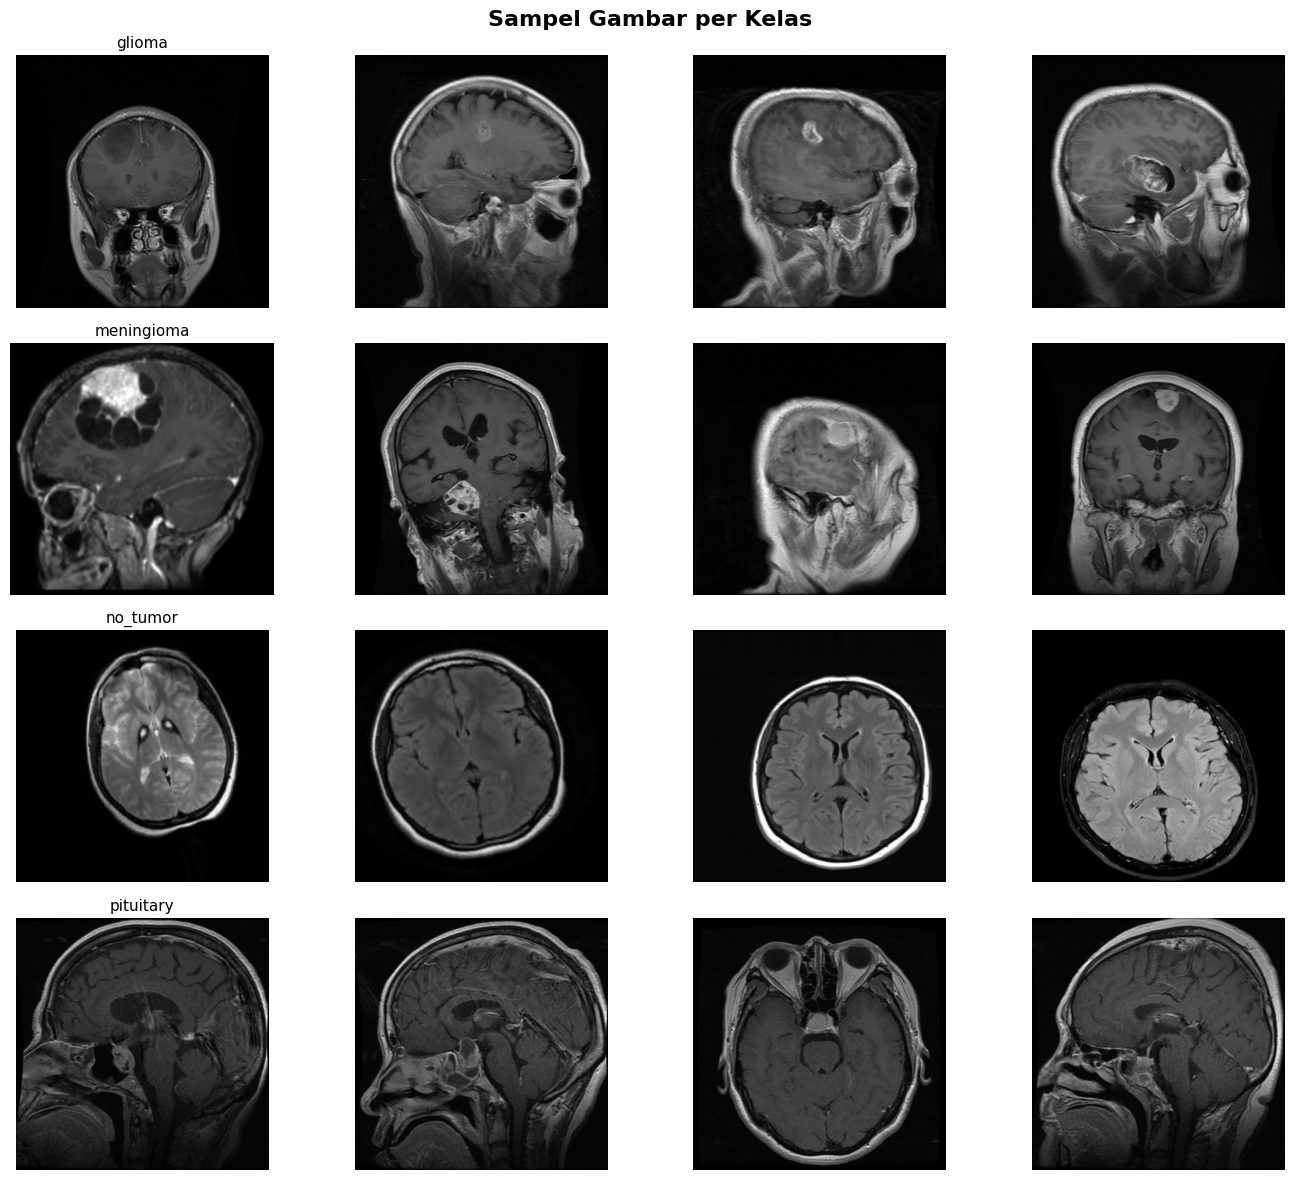

In [5]:
import matplotlib.image as mpimg

fig, axes = plt.subplots(len(classes), 4, figsize=(14, len(classes)*3))
fig.suptitle('Sampel Gambar per Kelas', fontsize=16, fontweight='bold')

for i, cls in enumerate(classes):
    cls_path = os.path.join(TRAIN_SRC, cls)
    images = os.listdir(cls_path)[:4]
    for j, img_name in enumerate(images):
        img = mpimg.imread(os.path.join(cls_path, img_name))
        axes[i][j].imshow(img, cmap='gray' if len(img.shape) == 2 else None)
        axes[i][j].set_title(cls if j == 0 else '', fontsize=11)
        axes[i][j].axis('off')

plt.tight_layout()
plt.show()


### Data Preprocessing

#### Split Dataset

Dataset di-split **manual** dari folder `train` Kaggle menjadi:
- **Train : 70%**
- **Validation : 15%**
- **Test : 15%**

Split dilakukan per kelas agar distribusi tetap seimbang (stratified).


In [6]:
import random
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ── Konfigurasi ──────────────────────────────────────────────
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
SEED       = 42
random.seed(SEED)

SPLIT_DIR = '/content/split_dataset'
TRAIN_DIR = os.path.join(SPLIT_DIR, 'train')
VAL_DIR   = os.path.join(SPLIT_DIR, 'validation')
TEST_DIR  = os.path.join(SPLIT_DIR, 'test')

# ── Split manual per kelas (stratified) ──────────────────────
if not os.path.exists(SPLIT_DIR):
    print('Membuat split dataset...')
    for split in ['train', 'validation', 'test']:
        for cls in classes:
            os.makedirs(os.path.join(SPLIT_DIR, split, cls), exist_ok=True)

    for cls in classes:
        src_cls  = os.path.join(TRAIN_SRC, cls)
        all_imgs = sorted(os.listdir(src_cls))  # sorted dulu agar deterministik
        random.shuffle(all_imgs)

        n       = len(all_imgs)
        n_train = int(n * 0.70)
        n_val   = int(n * 0.15)

        splits_map = {
            'train':      all_imgs[:n_train],
            'validation': all_imgs[n_train:n_train + n_val],
            'test':       all_imgs[n_train + n_val:]
        }

        for split_name, imgs in splits_map.items():
            for img in imgs:
                shutil.copy2(
                    os.path.join(src_cls, img),
                    os.path.join(SPLIT_DIR, split_name, cls, img)
                )

        print(f'  {cls:<15} → train: {len(splits_map["train"]):>4} | '
              f'val: {len(splits_map["validation"]):>4} | '
              f'test: {len(splits_map["test"]):>4}')

    print('\nSplit selesai!')
else:
    print('Split sudah ada, skip.')

# ── Verifikasi total ─────────────────────────────────────────
print()
for split in ['train', 'validation', 'test']:
    total = sum(len(os.listdir(os.path.join(SPLIT_DIR, split, c))) for c in classes)
    print(f'{split:<12}: {total} gambar')


Membuat split dataset...
  glioma          → train:  802 | val:  172 | test:  173
  meningioma      → train:  930 | val:  199 | test:  200
  no_tumor        → train:  746 | val:  160 | test:  161
  pituitary       → train: 1019 | val:  218 | test:  220

Split selesai!

train       : 3497 gambar
validation  : 749 gambar
test        : 754 gambar


In [7]:
# ── ImageDataGenerator ───────────────────────────────────────
# Augmentasi hanya untuk train, val & test hanya rescale
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    vertical_flip=False,
    brightness_range=[0.85, 1.15],
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Definisikan class_names di sini agar tersedia di semua cell berikutnya
class_names = list(train_generator.class_indices.keys())

print(f'Class indices     : {train_generator.class_indices}')
print(f'Class names       : {class_names}')
print(f'Train samples     : {train_generator.samples}')
print(f'Validation samples: {val_generator.samples}')
print(f'Test samples      : {test_generator.samples}')


Found 3497 images belonging to 4 classes.
Found 749 images belonging to 4 classes.
Found 754 images belonging to 4 classes.
Class indices     : {'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}
Class names       : ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Train samples     : 3497
Validation samples: 749
Test samples      : 754


## Modelling

Model dibangun menggunakan **Sequential CNN** murni sesuai kriteria, dengan arsitektur:
- 4 blok **Conv2D → BatchNormalization → MaxPooling2D**
- Filter bertahap: 32 → 64 → 128 → 256
- Classifier head: **GlobalAveragePooling2D → Dense(512) → Dropout(0.4) → Dense(256) → Dropout(0.3) → Softmax(4)**
- Input: 224×224×3

Overfitting dikontrol dengan:
- **BatchNormalization** di tiap blok
- **Dropout** bertingkat di classifier head
- **GlobalAveragePooling2D** menggantikan Flatten (lebih tahan overfitting)
- **L2 regularization** di Dense layer


In [8]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import GlobalAveragePooling2D

NUM_CLASSES = len(classes)

model = Sequential([
    # Block 1 — 32 filters
    Conv2D(32, (3,3), activation='relu', padding='same',
           input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Block 2 — 64 filters
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Block 3 — 128 filters
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Block 4 — 256 filters
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Classifier — GlobalAveragePooling lebih tahan overfitting dari Flatten
    GlobalAveragePooling2D(),
    Dense(512, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.4),
    Dense(256, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
], name='BrainTumorCNN')

model.summary()


Model: "BrainTumorCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 654,276 (2.50 MB)

 Trainable params: 653,316 (2.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 602ms/step - accuracy: 0.5648 - loss: 1.0795
Epoch 1: val_accuracy improved from None to 0.30174, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 96s 650ms/step - accuracy: 0.6365 - loss: 0.9382 - val_accuracy: 0.3017 - val_loss: 1.6090 - learning_rate: 0.0010
Epoch 2/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 575ms/step - accuracy: 0.6939 - loss: 0.7737
Epoch 2: val_accuracy improved from 0.30174 to 0.36716, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 65s 593ms/step - accuracy: 0.7341 - loss: 0.7044 - val_accuracy: 0.3672 - val_loss: 1.9697 - learning_rate: 0.0010
Epoch 3/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 555ms/step - accuracy: 0.7923 - loss: 0.6204
Epoch 3: val_accuracy improved from 0.36716 to 0.43525, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
110/110 ━━━━━━━━━━━━━━━━━━━━

## Evaluasi dan Visualisasi

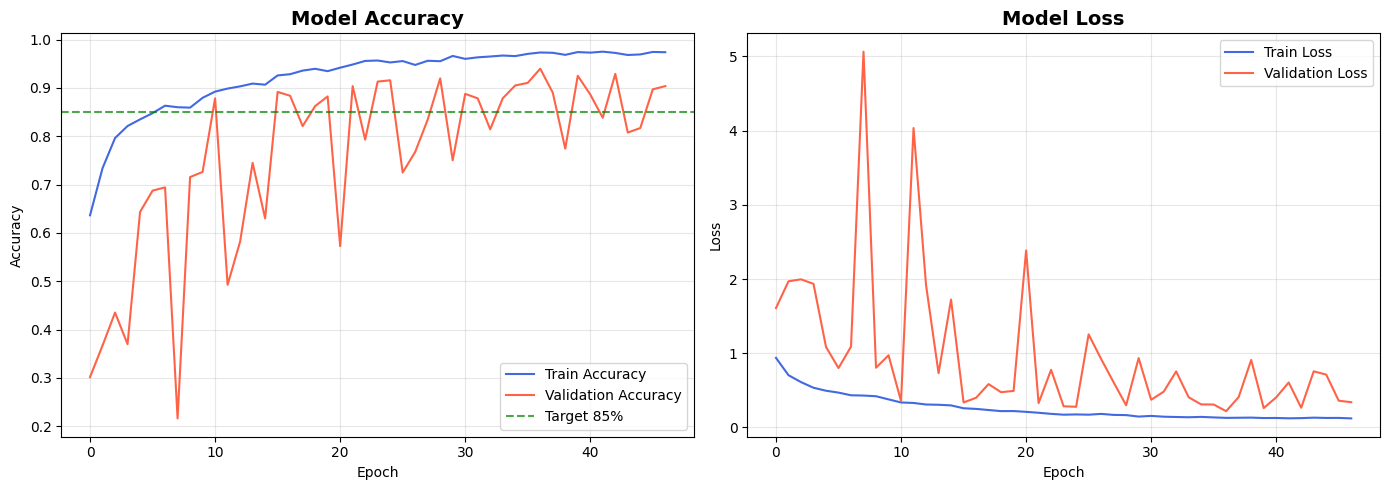

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train Accuracy',      color='royalblue')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='tomato')
axes[0].axhline(y=0.85, color='green', linestyle='--', alpha=0.7, label='Target 85%')
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train Loss',      color='royalblue')
axes[1].plot(history.history['val_loss'], label='Validation Loss', color='tomato')
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()


In [11]:
print('=' * 50)
print('EVALUASI MODEL PADA TEST SET')
print('=' * 50)

test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f'\nTest Loss    : {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')

# Akurasi training terakhir
train_acc_final = max(history.history['accuracy'])
print(f'\nBest Train Accuracy: {train_acc_final:.4f} ({train_acc_final*100:.2f}%)')

if test_acc >= 0.85:
    print('\n✅ Target akurasi ≥85% TERCAPAI!')
else:
    print('\n⚠️  Akurasi belum mencapai 85%. Coba tambah epoch atau tuning hyperparameter.')

EVALUASI MODEL PADA TEST SET
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 165ms/step - accuracy: 0.9204 - loss: 0.3280

Test Loss    : 0.3280
Test Accuracy: 0.9204 (92.04%)

Best Train Accuracy: 0.9751 (97.51%)

✅ Target akurasi ≥85% TERCAPAI!


24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step


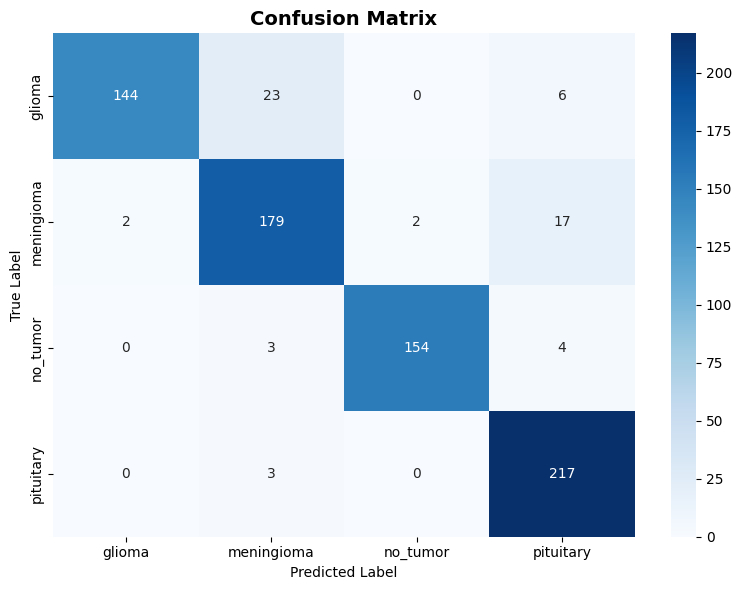


Classification Report:
              precision    recall  f1-score   support

      glioma       0.99      0.83      0.90       173
  meningioma       0.86      0.90      0.88       200
    no_tumor       0.99      0.96      0.97       161
   pituitary       0.89      0.99      0.94       220

    accuracy                           0.92       754
   macro avg       0.93      0.92      0.92       754
weighted avg       0.92      0.92      0.92       754



In [12]:
test_generator.reset()
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

# class_names sudah didefinisikan di cell preprocessing
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=class_names))


## Konversi Model

Model akan disimpan dalam 3 format:
1. **SavedModel** — deployment TensorFlow server/cloud
2. **TF-Lite** — deployment mobile & embedded
3. **TFJS** — deployment browser (JavaScript)

In [13]:
import os

os.makedirs('submission/saved_model', exist_ok=True)
os.makedirs('submission/tflite',      exist_ok=True)
os.makedirs('submission/tfjs_model',  exist_ok=True)

# ── 1. SavedModel ────────────────────────────────────────────
saved_model_path = 'submission/saved_model'

# Coba beberapa cara sesuai versi TF yang terinstall
try:
    # Cara 1: Keras 3 / TF 2.16+
    model.export(saved_model_path)
    print('SavedModel disimpan via model.export()')
except Exception:
    try:
        # Cara 2: TF 2.x klasik
        model.save(saved_model_path, save_format='tf')
        print('SavedModel disimpan via model.save(save_format=tf)')
    except Exception:
        # Cara 3: Lewat TFLiteConverter (fallback)
        tf.keras.saving.save_model(model, saved_model_path, save_format='tf')
        print('SavedModel disimpan via tf.keras.saving.save_model()')

print(f'Lokasi: {saved_model_path}')
!ls -lh submission/saved_model/


Saved artifact at 'submission/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  136110807768272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136110807769040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136110807770960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136110807771344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136110807767888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136110807770576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136110807770384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136110807771728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136110807772112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136110807772304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13611080

In [14]:
# ── 2. TF-Lite ───────────────────────────────────────────────
# Mengonversi dari SavedModel yang sudah disimpan (lebih stabil)
converter = tf.lite.TFLiteConverter.from_saved_model('submission/saved_model')
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

tflite_path = 'submission/tflite/model.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)
print(f'✅ TFLite disimpan di: {tflite_path}')
print(f'   Ukuran: {os.path.getsize(tflite_path) / 1024:.1f} KB')

# Menggunakan variabel 'classes' yang didefinisikan di awal
label_path = 'submission/tflite/label.txt'
with open(label_path, 'w') as f:
    for cls_name in classes:
        f.write(cls_name + '\n')
print(f'✅ Label disimpan di: {label_path}')

✅ TFLite disimpan di: submission/tflite/model.tflite
   Ukuran: 668.7 KB
✅ Label disimpan di: submission/tflite/label.txt


In [15]:
# ── 3. TFJS (Workaround using CLI to avoid Import Errors) ────────
!pip install tensorflowjs -q

tfjs_path = 'submission/tfjs_model'
saved_model_path = 'submission/saved_model'

# Menggunakan CLI converter karena library Python-nya konflik dengan TF 2.20
!tensorflowjs_converter \
    --input_format=tf_saved_model \
    --saved_model_tags=serve \
    {saved_model_path} \
    {tfjs_path}

print(f'✅ TFJS disimpan di: {tfjs_path}')
!ls -lh {tfjs_path}

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 98.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 7.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.19.0 which is incompatible.
xarray 2025.12.0 requires packaging>=24.1, but you have packaging 23.2 which is incompatible.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.19.

In [16]:
# ── Buat requirements.txt ────────────────────────────────────
reqs = [
    'tensorflow>=2.13.0',
    'numpy>=1.23.0',
    'matplotlib>=3.7.0',
    'seaborn>=0.12.0',
    'scikit-learn>=1.2.0',
    'tensorflowjs>=4.0.0',
    'Pillow>=9.0.0'
]

with open('submission/requirements.txt', 'w') as f:
    f.write('\n'.join(reqs))
print('requirements.txt dibuat')

# ── Buat README.md ────────────────────────────────────────────
readme_content = """# Brain Tumor Classification - Submission

## Deskripsi
Proyek klasifikasi gambar untuk mendeteksi jenis tumor otak menggunakan CNN.

## Dataset
**BRISC 2025 - Brain Tumor Classification**
- Sumber: Kaggle (briscdataset/brisc2025)
- Kelas: glioma, meningioma, pituitary, no_tumor
- Split: 70% train / 15% validation / 15% test (stratified per kelas)

## Arsitektur Model
Sequential CNN dengan 4 blok Conv2D:
- Block 1: Conv2D(32) + BatchNorm + MaxPooling2D
- Block 2: Conv2D(64) + BatchNorm + MaxPooling2D
- Block 3: Conv2D(128) + BatchNorm + MaxPooling2D
- Block 4: Conv2D(256) + BatchNorm + MaxPooling2D
- Head: GlobalAveragePooling2D → Dense(512) → Dropout(0.4) → Dense(256) → Dropout(0.3) → Softmax(4)
- Input size: 224x224x3

## Struktur Direktori
```
submission/
├── tfjs_model/
│   ├── group1-shard1of1.bin
│   └── model.json
├── tflite/
│   ├── model.tflite
│   └── label.txt
├── saved_model/
│   ├── saved_model.pb
│   └── variables/
├── notebook.ipynb
├── README.md
└── requirements.txt
```

## Cara Menjalankan
1. Install dependencies: `pip install -r requirements.txt`
2. Jalankan notebook: `notebook.ipynb`
"""

with open('submission/README.md', 'w') as f:
    f.write(readme_content)
print('README.md dibuat')

print('\nStruktur submission:')
!find submission -type f | sort


requirements.txt dibuat
README.md dibuat

Struktur submission:
submission/README.md
submission/requirements.txt
submission/saved_model/fingerprint.pb
submission/saved_model/saved_model.pb
submission/saved_model/variables/variables.data-00000-of-00001
submission/saved_model/variables/variables.index
submission/tfjs_model/group1-shard1of1.bin
submission/tfjs_model/model.json
submission/tflite/label.txt
submission/tflite/model.tflite


In [17]:
# ── Zip & Download ────────────────────────────────────────────
!cp notebook.ipynb submission/notebook.ipynb
!zip -r submission.zip submission/

from google.colab import files
files.download('submission.zip')
print('✅ submission.zip siap didownload!')

cp: cannot stat 'notebook.ipynb': No such file or directory
  adding: submission/ (stored 0%)
  adding: submission/requirements.txt (deflated 19%)
  adding: submission/saved_model/ (stored 0%)
  adding: submission/saved_model/variables/ (stored 0%)
  adding: submission/saved_model/variables/variables.data-00000-of-00001 (deflated 7%)
  adding: submission/saved_model/variables/variables.index (deflated 71%)
  adding: submission/saved_model/fingerprint.pb (stored 0%)
  adding: submission/saved_model/assets/ (stored 0%)
  adding: submission/saved_model/saved_model.pb (deflated 88%)
  adding: submission/tfjs_model/ (stored 0%)
  adding: submission/tfjs_model/model.json (deflated 92%)
  adding: submission/tfjs_model/group1-shard1of1.bin (deflated 7%)
  adding: submission/tflite/ (stored 0%)
  adding: submission/tflite/label.txt (deflated 5%)
  adding: submission/tflite/model.tflite (deflated 8%)
  adding: submission/README.md (deflated 49%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ submission.zip siap didownload!


## Inference (Optional)

Coba prediksi gambar baru menggunakan model yang sudah dilatih.

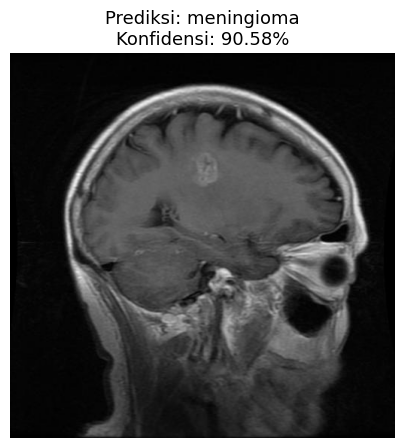

Probabilitas per kelas:
  glioma           8.73% ██
  meningioma      90.58% ███████████████████████████
  no_tumor         0.00% 
  pituitary        0.68% 


('meningioma', np.float32(90.58477))

In [18]:
from tensorflow.keras.preprocessing import image as keras_image

def predict_image(img_path, model, class_names, img_size=IMG_SIZE):
    """Prediksi satu gambar dan tampilkan hasilnya."""
    img       = keras_image.load_img(img_path, target_size=img_size)
    img_array = keras_image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    preds      = model.predict(img_array, verbose=0)
    pred_class = class_names[np.argmax(preds)]
    confidence = np.max(preds) * 100

    plt.figure(figsize=(5, 5))
    plt.imshow(keras_image.load_img(img_path))
    plt.title(f'Prediksi: {pred_class}\nKonfidensi: {confidence:.2f}%', fontsize=13)
    plt.axis('off')
    plt.show()

    print('Probabilitas per kelas:')
    for cls, prob in zip(class_names, preds[0]):
        bar = '█' * int(prob * 30)
        print(f'  {cls:<15} {prob*100:5.2f}% {bar}')

    return pred_class, confidence

# Ambil sample dari test set
sample_img = os.path.join(TEST_DIR, classes[0], os.listdir(os.path.join(TEST_DIR, classes[0]))[0])
predict_image(sample_img, model, class_names)


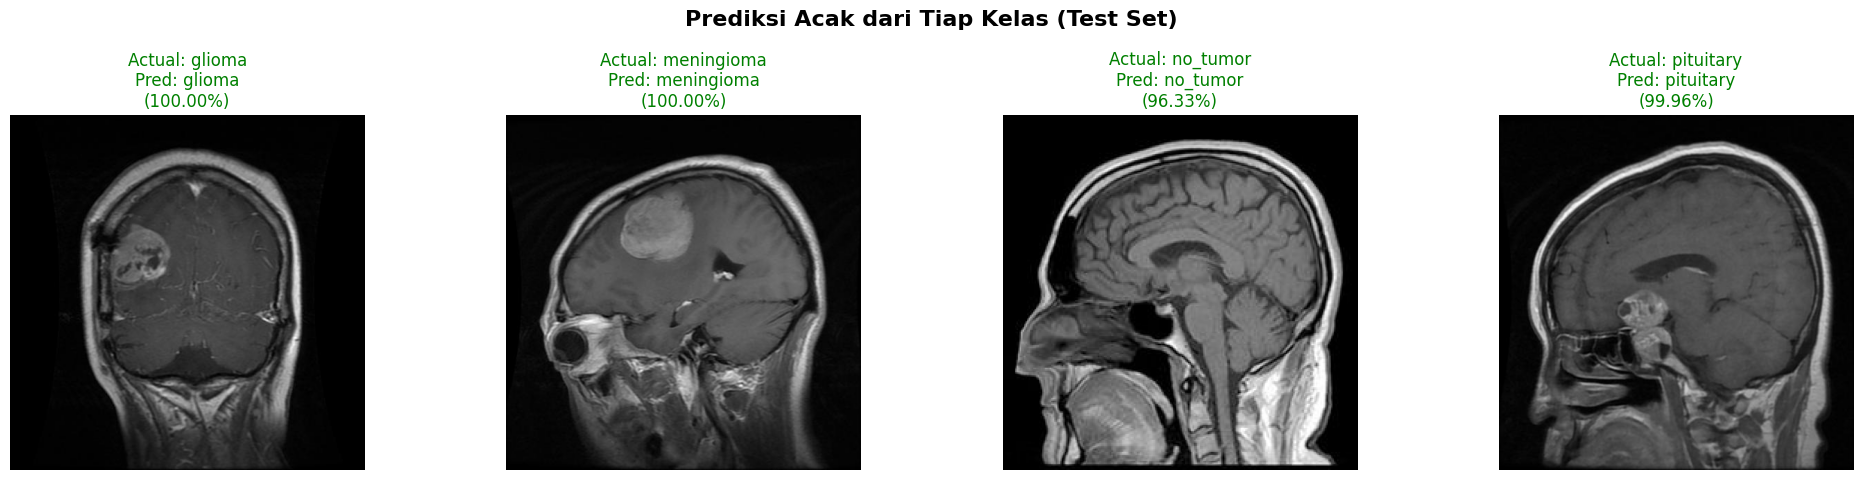

In [19]:
import random

# Ambil 1 gambar acak dari setiap kelas di folder test
fig, axes = plt.subplots(1, len(classes), figsize=(20, 5))
fig.suptitle('Prediksi Acak dari Tiap Kelas (Test Set)', fontsize=16, fontweight='bold')

for i, cls in enumerate(classes):
    cls_test_path = os.path.join(TEST_DIR, cls)
    random_img_name = random.choice(os.listdir(cls_test_path))
    img_path = os.path.join(cls_test_path, random_img_name)

    # Preprocessing
    img = keras_image.load_img(img_path, target_size=IMG_SIZE)
    img_array = keras_image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    preds = model.predict(img_array, verbose=0)
    pred_idx = np.argmax(preds)
    pred_class = class_names[pred_idx]
    confidence = np.max(preds) * 100

    # Visualisasi
    axes[i].imshow(keras_image.load_img(img_path))
    color = 'green' if pred_class == cls else 'red'
    axes[i].set_title(f'Actual: {cls}\nPred: {pred_class}\n({confidence:.2f}%)', color=color, fontsize=12)
    axes[i].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
#Malas run lagi nunggu colab runtime